In [1]:
# CELL 1 — W&B
import os, sys
os.environ['WANDB_API_KEY'] = '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'
os.environ['WANDB_MODE']    = 'online'
os.environ['WANDB_SILENT']  = 'true'
import wandb
wandb.login(key=os.environ['WANDB_API_KEY'], relogin=True)
print('✅ W&B ready')

✅ W&B ready


In [2]:
# CELL 2 — Copy files
import shutil, os, sys
DATASET = None
for root, dirs, files in os.walk('/kaggle/input'):
    if 'transforms.py' in files:
        DATASET = root; break
assert DATASET, 'Add code dataset as input'
print(f'✅ {DATASET}')
for f in ['transforms.py','rothermel.py','trainer.py','wildfire_dataset.py',
          'notebook_1_resnet_unet.py','notebook_2_swin_unet.py','notebook_4_comparison.py']:
    src = os.path.join(DATASET, f)
    if os.path.exists(src):
        shutil.copy(src, f'/kaggle/working/{f}'); print(f'✅ {f}')
    else:
        print(f'⚠️  missing: {f}')
os.makedirs('/kaggle/working/outputs/checkpoints', exist_ok=True)
sys.path.insert(0, '/kaggle/working')
print('✅ done')

✅ /kaggle/input/datasets/toshitdwivedi/forest-fire-transformers-py
✅ transforms.py
✅ rothermel.py
✅ trainer.py
✅ wildfire_dataset.py
✅ notebook_1_resnet_unet.py
✅ notebook_2_swin_unet.py
✅ notebook_4_comparison.py
✅ done


In [3]:
# CELL 3 — Build HDF5 with all 3 splits
import h5py, os, tensorflow as tf, numpy as np
from tqdm.auto import tqdm
HDF5_PATH = '/kaggle/working/wildfire_data.h5'
if os.path.exists(HDF5_PATH):
    with h5py.File(HDF5_PATH,'r') as f:
        keys = list(f.keys())
    if 'train' in keys and 'eval' in keys and 'test' in keys:
        print(f'✅ HDF5 complete {os.path.getsize(HDF5_PATH)/1e9:.2f}GB'); needs_rebuild=False
    else:
        print(f'⚠️  incomplete splits {keys} — rebuilding'); os.remove(HDF5_PATH); needs_rebuild=True
else:
    needs_rebuild=True
if needs_rebuild:
    TFREC_DIR='/kaggle/input/datasets/fantineh/next-day-wildfire-spread'
    CHANNELS=['elevation','th','vs','tmmn','tmmx','sph','pr','pdsi','NDVI','population','erc','PrevFireMask']
    TARGET='FireMask'; SZ=64
    FEAT={n:tf.io.FixedLenFeature([SZ,SZ],tf.float32) for n in CHANNELS+[TARGET]}
    def parse(s):
        p=tf.io.parse_single_example(s,FEAT)
        return tf.stack([p[c] for c in CHANNELS],axis=-1),p[TARGET]
    files=sorted([os.path.join(TFREC_DIR,f) for f in os.listdir(TFREC_DIR) if 'tfrecord' in f])
    splits={s:[f for f in files if f'_{s}_' in os.path.basename(f)] for s in ('train','eval','test')}
    for s,fs in splits.items(): print(f'  {s}: {len(fs)} shards')
    with h5py.File(HDF5_PATH,'w') as hf:
        for split,sfiles in splits.items():
            g=hf.require_group(split)
            di=g.create_dataset('inputs', shape=(0,SZ,SZ,12),maxshape=(None,SZ,SZ,12),dtype='float32',chunks=(32,SZ,SZ,12),compression='gzip',compression_opts=4)
            dt=g.create_dataset('targets',shape=(0,SZ,SZ),  maxshape=(None,SZ,SZ),  dtype='float32',chunks=(32,SZ,SZ),  compression='gzip',compression_opts=4)
            ds=tf.data.TFRecordDataset(sfiles).map(parse,num_parallel_calls=tf.data.AUTOTUNE).batch(128).prefetch(2)
            idx=0
            for ib,tb in tqdm(ds,desc=f'  {split}'):
                n=ib.shape[0]; di.resize(idx+n,axis=0); dt.resize(idx+n,axis=0)
                di[idx:idx+n]=ib.numpy(); dt[idx:idx+n]=tb.numpy(); idx+=n
            print(f'  {split}: {idx:,} samples')
    print(f'✅ HDF5 {os.path.getsize(HDF5_PATH)/1e9:.2f}GB')

2026-05-22 18:05:50.305229: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779473150.546242      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779473150.613758      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779473151.141977      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779473151.142023      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779473151.142026      24 computation_placer.cc:177] computation placer alr

  train: 15 shards
  eval: 2 shards
  test: 2 shards


I0000 00:00:1779473179.065749      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779473179.072394      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


  train: 0it [00:00, ?it/s]

  train: 14,979 samples


  eval: 0it [00:00, ?it/s]

  eval: 1,877 samples


  test: 0it [00:00, ?it/s]

  test: 1,689 samples
✅ HDF5 2.54GB


In [4]:
# CELL 4 — Sanity check
import torch, h5py
print(f'GPU : {torch.cuda.get_device_name(0)}')
print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f}GB')
with h5py.File('/kaggle/working/wildfire_data.h5','r') as f:
    for s in ['train','eval','test']:
        print(f'  {s} inputs: {f[s+"/inputs"].shape}  targets: {f[s+"/targets"].shape}')
print('✅ ready')

GPU : Tesla T4
VRAM: 15.6GB
  train inputs: (14979, 64, 64, 12)  targets: (14979, 64, 64)
  eval inputs: (1877, 64, 64, 12)  targets: (1877, 64, 64)
  test inputs: (1689, 64, 64, 12)  targets: (1689, 64, 64)
✅ ready


Device: cuda
GPU   : Tesla T4
VRAM  : 15.6 GB
✅ ResNetUNet output shape: torch.Size([2, 1, 128, 128])
   Trainable params: 67.52M
✅ HDF5 exists (2.54 GB)
Dataset split sizes:
  train : 14,979 samples  (1248 batches)
  val   : 1,877 samples  (157 batches)
  test  : 1,689 samples  (141 batches)

Batch shapes:
  inputs   : torch.Size([12, 24, 128, 128])
  targets  : torch.Size([12, 1, 128, 128])
  prev_fire: torch.Size([12, 1, 128, 128])
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 162MB/s]


Trainable params (decoder only): 67.52M
✅ WandB online logging enabled
No checkpoint found — starting from epoch 1

Training: resnet_unet
Device  : cuda
Epochs  : 1 → 50
Ckpt dir: /kaggle/working/outputs/checkpoints/resnet_unet



/kaggle/working/trainer.py:881: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.config.mixed_precision):
/kaggle/working/trainer.py:949: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.config.mixed_precision):


Epoch   1/50 | Loss=0.9770 (dice=0.962 focal=0.015 pde=0.000) | CSI=0.1363 | λ_pde=0.000 | LR=2.8e-05 | t=400.5s
  ★ New best CSI=0.1363 → /kaggle/working/outputs/checkpoints/resnet_unet/best_model.pt


...

Epoch  49/50 | Loss=0.0000 (dice=0.000 focal=0.000 pde=0.000) | CSI=0.0000 | λ_pde=0.000 | LR=5.6e-05 | t=379.9s


/kaggle/working/trainer.py:881: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.config.mixed_precision):
/kaggle/working/trainer.py:949: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.config.mixed_precision):


Epoch  50/50 | Loss=0.0000 (dice=0.000 focal=0.000 pde=0.000) | CSI=0.0000 | λ_pde=0.000 | LR=5.5e-05 | t=385.5s
  ✓ Checkpoint saved: /kaggle/working/outputs/checkpoints/resnet_unet/checkpoint_epoch_50.pt

✅ Training complete. Best CSI = 0.1760

Total training time: 5.58 hours

TEST SET EVALUATION — ResNet-UNet


/kaggle/working/trainer.py:949: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.config.mixed_precision):


  CSI                 : 0.0000
  IoU                 : 0.0000
  Precision           : 0.0000
  Recall              : 0.0000
  F1                  : 0.0000
  PR-AUC              : nan
  PCR                 : 1.0000
  ECE                 : 0.0000
  Fréchet dist        : nan

  Params         : 67.52M
  Train time     : 5.58h

✅ Results saved to /kaggle/working/results_resnet_unet.json


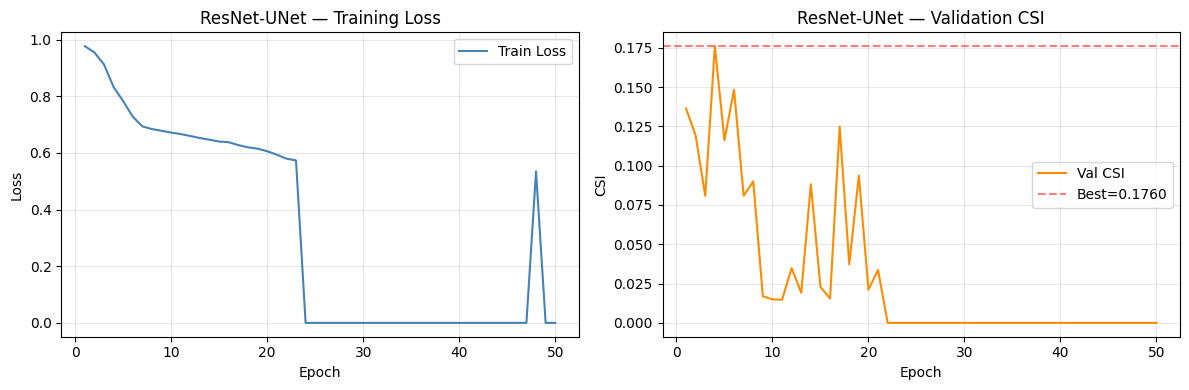

Plot saved: /kaggle/working/curve_resnet_unet.png


In [5]:
# CELL 5 — Train ResNet-UNet
for mod in list(sys.modules.keys()):
    if any(x in mod for x in ['wildfire_dataset','trainer','transforms','rothermel']):
        del sys.modules[mod]
exec(open('/kaggle/working/notebook_1_resnet_unet.py').read())

In [6]:
# CELL 6 — Clear VRAM + Train Swin-UNet
import torch, gc
try: del model,trainer,optimizer,train_dl,val_dl,test_dl,scheduler,loss_fn,config
except: pass
gc.collect(); torch.cuda.empty_cache()
print(f'VRAM reserved: {torch.cuda.memory_reserved()/1e9:.1f}GB')
for mod in list(sys.modules.keys()):
    if any(x in mod for x in ['wildfire_dataset','trainer','transforms','rothermel']):
        del sys.modules[mod]
exec(open('/kaggle/working/notebook_2_swin_unet.py').read())

VRAM reserved: 0.9GB
Device: cuda
GPU   : Tesla T4
VRAM  : 15.6 GB
✅ SwinUNet output shape: torch.Size([2, 1, 128, 128])
   Trainable params: 30.11M
Dataset split sizes:
  train : 14,979 samples  (1872 batches)
  val   : 1,877 samples  (235 batches)
  test  : 1,689 samples  (212 batches)
Batch shapes — inputs: torch.Size([8, 24, 128, 128])  targets: torch.Size([8, 1, 128, 128])


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/timm/layers/interpolate.py:47: UserWarning: torch.searchsorted(): input value tensor is non-contiguous, this will lower the performance due to extra data copy when converting non-contiguous tensor to contiguous, please use contiguous input value tensor if possible. This message will only appear once per program. (Triggered internally at /pytorch/aten/src/ATen/native/BucketizationUtils.h:32.)
  idx_right = torch.bucketize(x, p)
/usr/local/lib/python3.12/dist-packages/timm/layers/interpolate.py:65: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:347.)
  numerator += self.values[as_s] * \


✅ WandB online logging enabled
No checkpoint found — starting from epoch 1

Training: swin_unet
Device  : cuda
Epochs  : 1 → 50
Ckpt dir: /kaggle/working/outputs/checkpoints/swin_unet



/kaggle/working/trainer.py:881: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.config.mixed_precision):
/kaggle/working/trainer.py:949: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.config.mixed_precision):


...

Epoch  49/50 | Loss=0.0000 (dice=0.000 focal=0.000 pde=0.000) | CSI=0.0000 | λ_pde=0.000 | LR=5.6e-05 | t=388.0s


/kaggle/working/trainer.py:881: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.config.mixed_precision):
/kaggle/working/trainer.py:949: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.config.mixed_precision):


Epoch  50/50 | Loss=0.0000 (dice=0.000 focal=0.000 pde=0.000) | CSI=0.0000 | λ_pde=0.000 | LR=5.5e-05 | t=382.3s
  ✓ Checkpoint saved: /kaggle/working/outputs/checkpoints/swin_unet/checkpoint_epoch_50.pt

✅ Training complete. Best CSI = 0.1800

Total training time: 5.58 hours


/kaggle/working/trainer.py:949: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=self.config.mixed_precision):



TEST SET EVALUATION — Swin-UNet
  CSI                 : 0.0000
  IoU                 : 0.0000
  Precision           : 0.0000
  Recall              : 0.0000
  F1                  : 0.0000
  PR_AUC              : nan
  PCR                 : 1.0000
  ECE                 : 0.0000
  Frechet_dist        : nan
  val_total           : nan
  val_seg             : nan
  val_dice            : nan
  val_focal           : nan
✅ Results saved to /kaggle/working/results_swin_unet.json
